# From Self-Attention mechanism to Transformers

This notebook aims to provide a comprehensive and practical understanding of the self-attention mechanism and its applications in various contexts, through detailed explanations, visualizations and interactive exercises.

## Self-Attention mechanism: basic implementation

Here is an example of Python code using TensorFlow and Matplotlib to explain and visualize the Self-Attention mechanism. This code shows intermediate steps such as generating queries, keys, and values ​​matrices, as well as calculating attention scores and applying attention weights to values. .

![image.png](attachment:image.png)

![image-2.png](attachment:image-2.png)

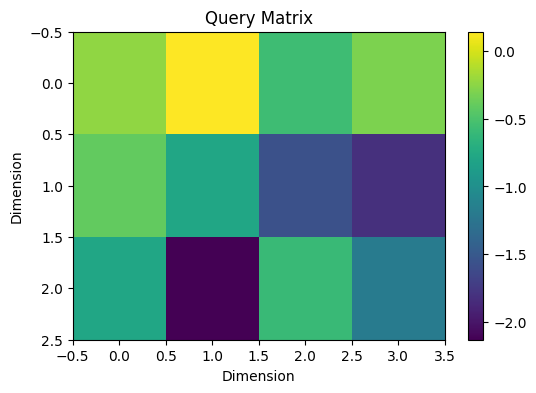

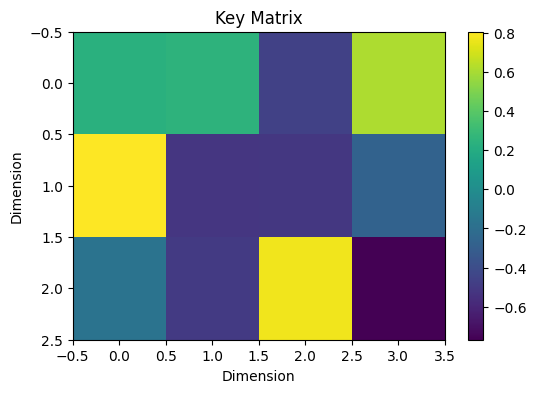

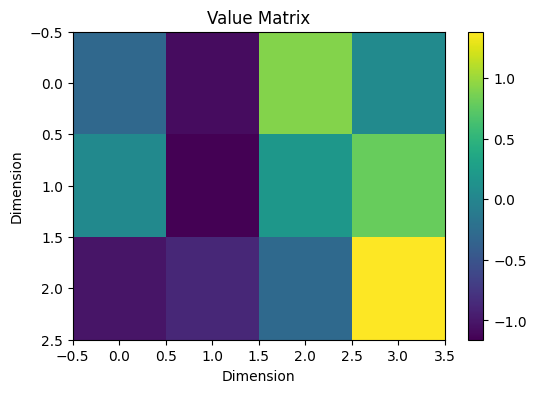

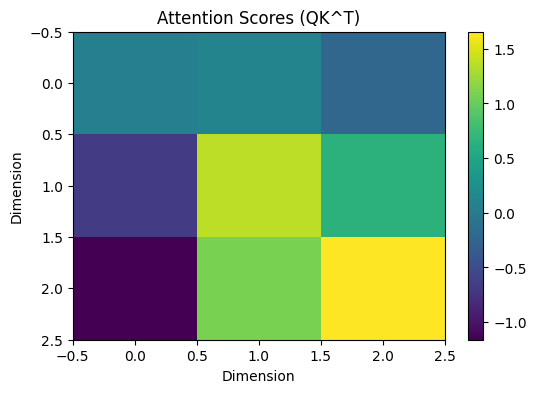

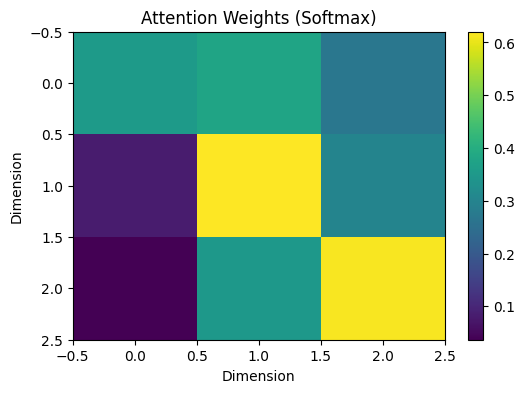

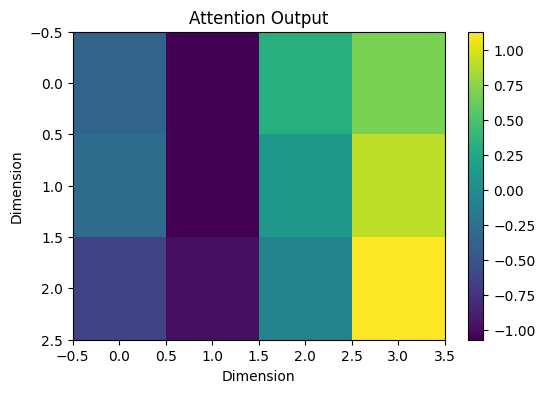

Input Sequence:
 [[1. 0. 1. 0.]
 [0. 2. 1. 0.]
 [1. 1. 0. 1.]]

Query Matrix:
 [[-0.23429269  0.1391468  -0.56769943 -0.30950627]
 [-0.40490574 -0.78787917 -1.5710299  -1.812947  ]
 [-0.790537   -2.1293075  -0.5895833  -1.1823571 ]]

Key Matrix:
 [[ 0.23256522  0.24957466 -0.4638762   0.6080631 ]
 [ 0.8045401  -0.51695555 -0.5105426  -0.27199477]
 [-0.16638732 -0.5024375   0.7689188  -0.76784164]]

Value Matrix:
 [[-0.3027591  -1.0715373   0.9148191   0.05580994]
 [ 0.05193824 -1.1592822   0.18550593  0.7904047 ]
 [-1.0119001  -0.879658   -0.28943175  1.3849955 ]]

Attention Scores (QK^T):
 [[ 0.05538209  0.11358825 -0.22979222]
 [-0.66442454  1.3767253   0.647293  ]
 [-1.1607268   1.087341    1.6559006 ]]

Attention Weights:
 [[0.35564196 0.37695682 0.26740122]
 [0.08056718 0.6203236  0.29910925]
 [0.03677852 0.34827128 0.61495024]]

Attention Output:
 [[-0.3586787  -1.0533046   0.3178814   0.68814623]
 [-0.2948426  -1.0685747   0.10220639  0.9090681 ]
 [-0.6153146  -0.98410016 -0.079

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(0)

def plot_matrix(matrix, title):
    """Affiche une matrice avec une échelle de couleurs."""
    plt.figure(figsize=(6, 4))
    plt.imshow(matrix, cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Dimension")
    plt.ylabel("Dimension")
    plt.show()


input_sequence = np.array([
    [1, 0, 1, 0],
    [0, 2, 1, 0],
    [1, 1, 0, 1]
], dtype=np.float32)


d_model = input_sequence.shape[1]


dense_q = tf.keras.layers.Dense(d_model)
dense_k = tf.keras.layers.Dense(d_model)
dense_v = tf.keras.layers.Dense(d_model)

Q = dense_q(input_sequence)
K = dense_k(input_sequence)
V = dense_v(input_sequence)

plot_matrix(Q.numpy(), "Query Matrix")
plot_matrix(K.numpy(), "Key Matrix")
plot_matrix(V.numpy(), "Value Matrix")

scores = tf.matmul(Q, K, transpose_b=True)
plot_matrix(scores.numpy(), "Attention Scores (QK^T)")

attention_weights = tf.nn.softmax(scores, axis=-1)
plot_matrix(attention_weights.numpy(), "Attention Weights (Softmax)")

attention_output = tf.matmul(attention_weights, V)
plot_matrix(attention_output.numpy(), "Attention Output")

print("Input Sequence:\n", input_sequence)
print("\nQuery Matrix:\n", Q.numpy())
print("\nKey Matrix:\n", K.numpy())
print("\nValue Matrix:\n", V.numpy())
print("\nAttention Scores (QK^T):\n", scores.numpy())
print("\nAttention Weights:\n", attention_weights.numpy())
print("\nAttention Output:\n", attention_output.numpy())


### Detailed Explanations of Each Step
#### Input Sequence: The input sequence is a matrix where each row represents a feature vector for an element of the sequence. This is the data we want to apply self-attention to.

#### Query, Key, and Value Matrices: These matrices are created by applying linear transformations (Dense layers) to the input sequence.
- Queries: Used to compare against keys to measure similarity.
- Keys: Used in conjunction with queries to compute attention scores.
- Values: Contain the information we want to focus on and extract based on the computed attention scores.

#### Attention Scores:

- Calculated by taking the dot product of the query matrix and the transposed key matrix.
- This gives a measure of similarity between elements of the sequence.

#### Attention Weights:

- The scores are passed through a softmax function to convert them into probabilities (attention weights).
- These weights determine the relative importance of each element in the sequence.

#### Attention Output:

- The attention weights are applied to the value matrix to compute the final attention output.
- This output represents the weighted sum of values based on their attention weights, capturing the relevant information from the input sequence.

### Visualizations
- Query, Key, and Value Matrices: Visualized to understand how the input sequence is transformed.
- Attention Scores: Show the similarity measures between different elements of the sequence.
- Attention Weights: Show the normalized importance of each element in the sequence.
- Attention Output: The final weighted output that captures the important information based on the attention mechanism.

## Self-Attention mechanism: Using a sentence as input

The sentence "I love tennis" is represented using embeddings, and the self-attention mechanism is applied to transform these embeddings.

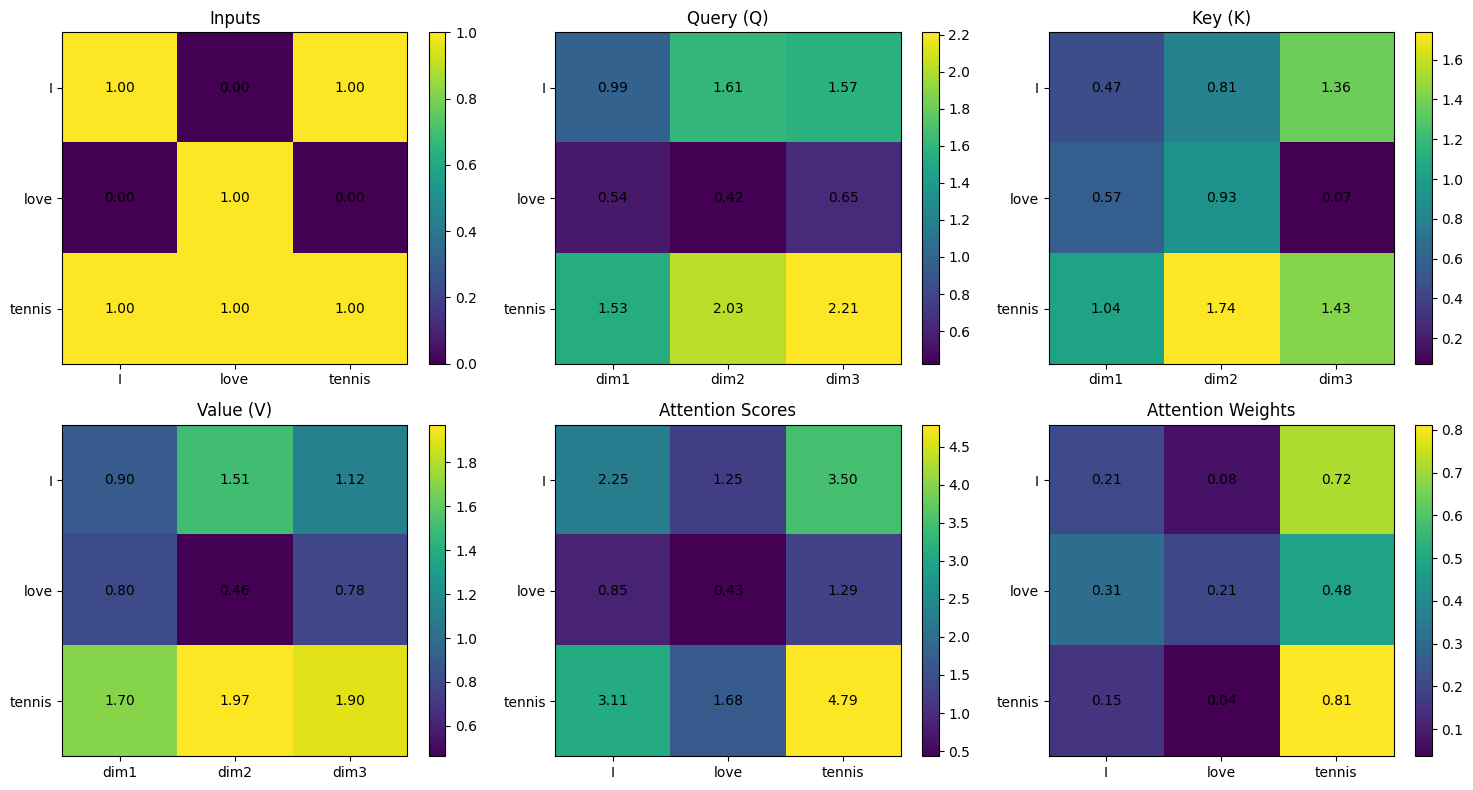

Phrase: ['I', 'love', 'tennis']

Inputs:
 [[1. 0. 1.]
 [0. 1. 0.]
 [1. 1. 1.]]

Query (Q):
 [[0.98640072 1.60696237 1.56642614]
 [0.54488318 0.4236548  0.64589411]
 [1.5312839  2.03061717 2.21232025]]

Key (K):
 [[0.47057082 0.81194344 1.36151477]
 [0.56804456 0.92559664 0.07103606]
 [1.03861538 1.73754007 1.43255082]]

Value (V):
 [[0.89643118 1.50993317 1.12197163]
 [0.79915856 0.46147936 0.78052918]
 [1.69558974 1.97141253 1.90250081]]

Attention Scores:
 [[2.25261651 1.24649419 3.4991107 ]
 [0.85435382 0.43158847 1.28594229]
 [3.10697034 1.67808266 4.78505299]]

Attention Weights:
 [[0.2064511  0.07548555 0.71806334]
 [0.31299554 0.20508481 0.48191965]
 [0.15163339 0.03632761 0.812039  ]]

Output:
 [[1.46293497 1.76216147 1.65666705]
 [1.26161226 1.5173072  1.42809932]
 [1.54184542 1.84658459 1.74338797]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def plot_heatmap(matrix, title, x_labels=None, y_labels=None, subplot_pos=111):
    ax = plt.subplot(subplot_pos)
    im = ax.imshow(matrix, aspect='auto')
    ax.set_title(title)

    # Labels des axes
    if x_labels is not None:
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels)
    else:
        ax.set_xticks(range(matrix.shape[1]))

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels)
    else:
        ax.set_yticks(range(matrix.shape[0]))

    # Afficher les valeurs dans chaque cellule
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", color="black")

    plt.colorbar(im, ax=ax)

embeddings = {
    "I":      [1, 0, 1],
    "love":   [0, 1, 0],
    "tennis": [1, 1, 1]
}

sentence = ["I", "love", "tennis"]

inputs = np.array([embeddings[w] for w in sentence], dtype=float)

np.random.seed(0)

Wq = np.random.rand(3, 3)
Wk = np.random.rand(3, 3)
Wv = np.random.rand(3, 3)

Q = inputs @ Wq
K = inputs @ Wk
V = inputs @ Wv

d_k = K.shape[1]
scores = (Q @ K.T) / np.sqrt(d_k)
attention_weights = softmax(scores)
output = attention_weights @ V

plt.figure(figsize=(15, 8))

plot_heatmap(inputs, "Inputs",
             x_labels=sentence, y_labels=sentence, subplot_pos=231)

plot_heatmap(Q, "Query (Q)",
             x_labels=["dim1", "dim2", "dim3"],
             y_labels=sentence, subplot_pos=232)

plot_heatmap(K, "Key (K)",
             x_labels=["dim1", "dim2", "dim3"],
             y_labels=sentence, subplot_pos=233)

plot_heatmap(V, "Value (V)",
             x_labels=["dim1", "dim2", "dim3"],
             y_labels=sentence, subplot_pos=234)

plot_heatmap(scores, "Attention Scores",
             x_labels=sentence, y_labels=sentence, subplot_pos=235)

plot_heatmap(attention_weights, "Attention Weights",
             x_labels=sentence, y_labels=sentence, subplot_pos=236)

plt.tight_layout()
plt.show()
print("Phrase:", sentence)
print("\nInputs:\n", inputs)
print("\nQuery (Q):\n", Q)
print("\nKey (K):\n", K)
print("\nValue (V):\n", V)
print("\nAttention Scores:\n", scores)
print("\nAttention Weights:\n", attention_weights)
print("\nOutput:\n", output)


![image.png](attachment:image.png)

## Self-Attention mechanism: Word embeddings computing

To demonstrate a basic self-attention mechanism with real embeddings, we'll use a simple approach to compute word embeddings based on co-occurrence statistics from the given sentence. Here, I'll provide a complete example including the calculation of basic word embeddings and applying the self-attention mechanism.

### Step-by-Step Process
 - Tokenize the Sentence: We'll split the sentence into individual words (tokens).

 - Calculate Word Embeddings: We'll use a basic technique to create embeddings based on the context of each word. In this case, we'll use one-hot encoding as the simplest form of embedding.

 - Apply Self-Attention: Using the calculated embeddings, we'll apply the self-attention mechanism and visualize the intermediate results.

 - Initialize Weights: Random weights for Query (Q), Key (K), and Value (V) matrices are initialized.

 - Compute Q, K, and V Matrices: The input embeddings are transformed into Q, K, and V matrices using the initialized weights.

 - Compute Attention Scores: Attention scores are calculated by taking the dot product of Q and K transpose, then normalizing by the square root of the key dimension.

 - Apply Softmax to Get Attention Weights: The softmax function is applied to the attention scores to obtain the attention weights.

- Compute the Output: The final output is calculated by multiplying the attention weights with the value matrix V.

 - Visualization: Various stages of the self-attention mechanism (inputs, Q, K, V matrices, attention scores, and attention weights) are visualized using heatmaps.

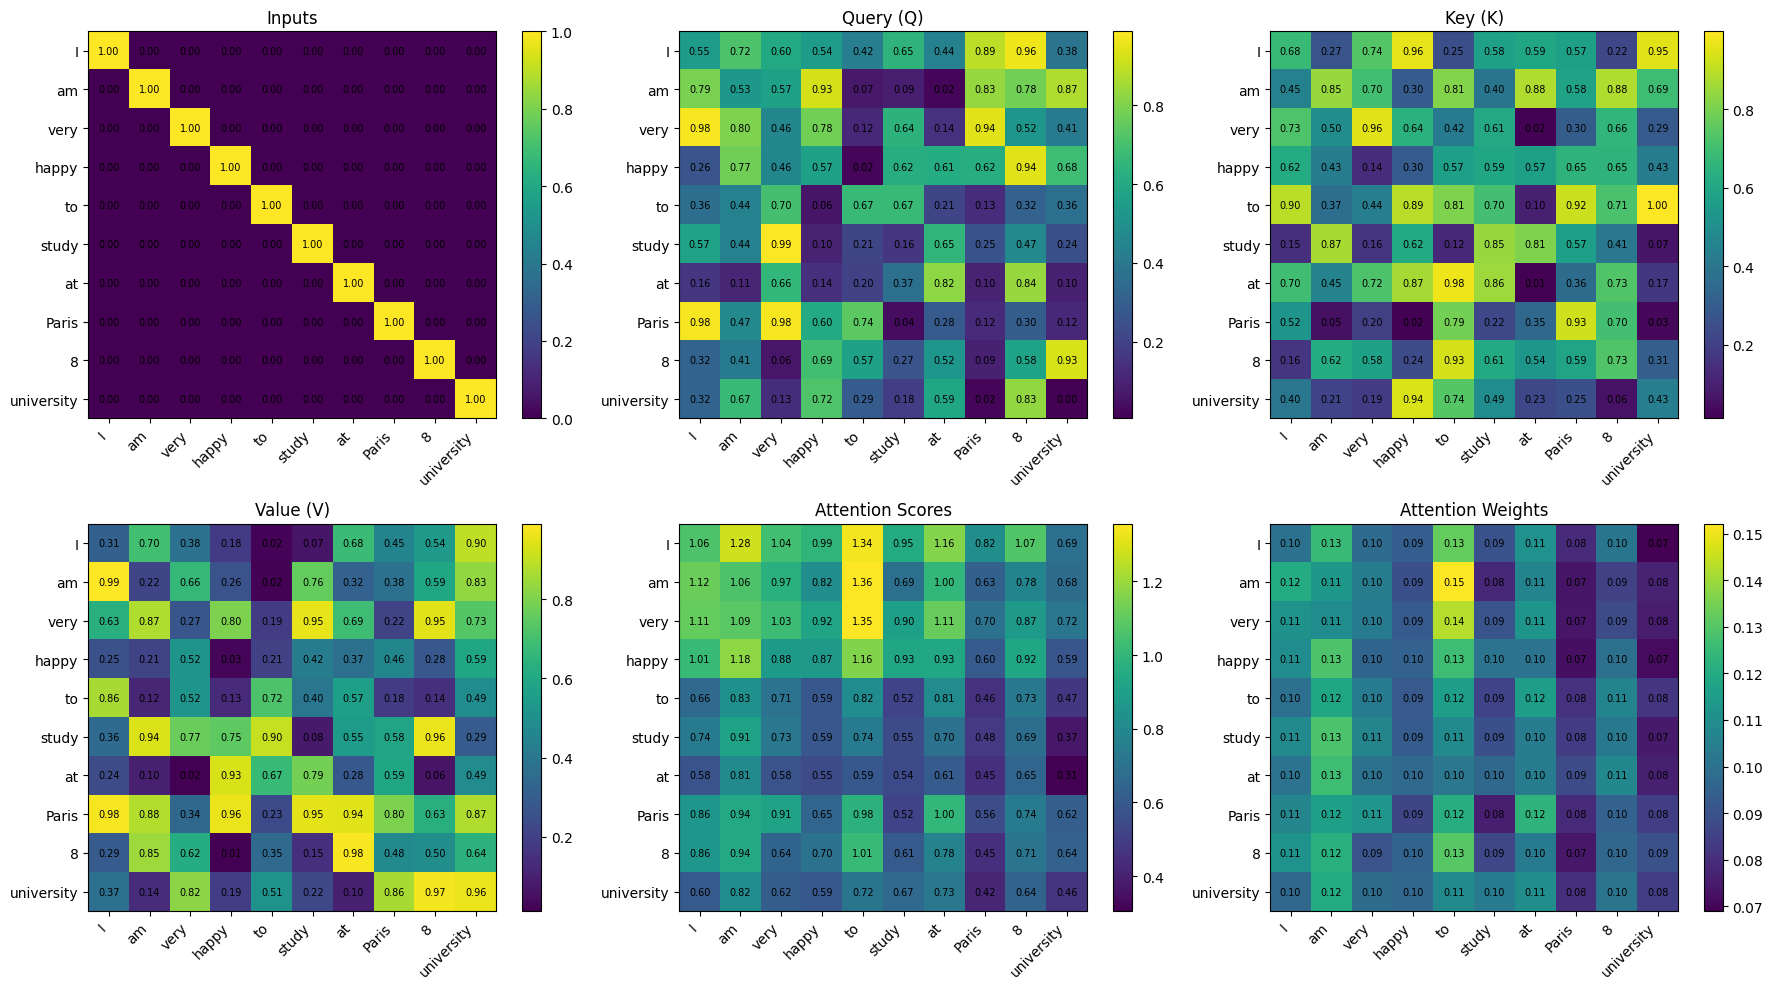

Sentence: ['I', 'am', 'very', 'happy', 'to', 'study', 'at', 'Paris', '8', 'university']

Inputs:
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Query (Q):
 [[0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
  0.43758721 0.891773   0.96366276 0.38344152]
 [0.79172504 0.52889492 0.56804456 0.92559664 0.07103606 0.0871293
  0.0202184  0.83261985 0.77815675 0.87001215]
 [0.97861834 0.79915856 0.46147936 0.78052918 0.11827443 0.63992102
  0.14335329 0.94466892 0.52184832 0.41466194]
 [0.26455561 0.77423369 0.45615033 0.56843395 0.0187898  0.6176355
  0.61209572 0.616934   0.94374808 0.6818203 ]
 [0.3595079  0.43703195 0.6976312  0.06022547 0.66676672 0.67063787
  0.21038256 0.1289263  0.315428

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def plot_matrix(matrix, title, x_labels=None, y_labels=None, position=111):
    ax = plt.subplot(position)
    img = ax.imshow(matrix, aspect="auto")
    ax.set_title(title)

    if x_labels is not None:
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=45, ha="right")
    else:
        ax.set_xticks(range(matrix.shape[1]))

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels)
    else:
        ax.set_yticks(range(matrix.shape[0]))

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", color="black", fontsize=7)

    plt.colorbar(img, ax=ax)


sentence = "I am very happy to study at Paris 8 university".split()
n_words = len(sentence)

word_to_idx = {word: i for i, word in enumerate(sentence)}
identity = np.eye(n_words)

inputs = np.array([identity[word_to_idx[w]] for w in sentence], dtype=float)

np.random.seed(0)

Wq = np.random.rand(n_words, n_words)
Wk = np.random.rand(n_words, n_words)
Wv = np.random.rand(n_words, n_words)

Q = inputs @ Wq
K = inputs @ Wk
V = inputs @ Wv

d_k = K.shape[1]
scores = (Q @ K.T) / np.sqrt(d_k)
attention_weights = softmax(scores)
output = attention_weights @ V

plt.figure(figsize=(18, 10))

plot_matrix(inputs, "Inputs",
            x_labels=sentence, y_labels=sentence, position=231)

plot_matrix(Q, "Query (Q)",
            x_labels=sentence, y_labels=sentence, position=232)

plot_matrix(K, "Key (K)",
            x_labels=sentence, y_labels=sentence, position=233)

plot_matrix(V, "Value (V)",
            x_labels=sentence, y_labels=sentence, position=234)

plot_matrix(scores, "Attention Scores",
            x_labels=sentence, y_labels=sentence, position=235)

plot_matrix(attention_weights, "Attention Weights",
            x_labels=sentence, y_labels=sentence, position=236)

plt.tight_layout()
plt.show()

print("Sentence:", sentence)
print("\nInputs:\n", inputs)
print("\nQuery (Q):\n", Q)
print("\nKey (K):\n", K)
print("\nValue (V):\n", V)
print("\nAttention Scores:\n", scores)
print("\nAttention Weights:\n", attention_weights)
print("\nOutput:\n", output)


![image.png](attachment:image.png)

## Complete Encoder Implementation

The encoder implementation involves several key steps, each contributing to transforming the input data and capturing relationships and context within a sentence. Here’s a detailed explanation of each step:


1. Tokenization and Embedding

 - Tokenization: The input sentence "I am very happy to work at Paris 8 university" is split into individual words (tokens), creating a list of tokens.

 - Embedding: Each word in the sentence is represented using one-hot encoding, which is a basic form of word embedding. In one-hot encoding, each word is represented by a unique vector where only one element is 1 (indicating the presence of the word), and all other elements are 0.

2. Initialize Weights

 - Weight Initialization: Random weights are initialized for the Query (Q), Key (K), and Value (V) matrices, as well as for the feed-forward neural network layers. These weights will be used to transform the input embeddings during the self-attention and feed-forward processes.

3. Self-Attention Layer

 - Compute Q, K, and V Matrices: The input embeddings are multiplied by the respective weight matrices to obtain the Q, K, and V matrices. These matrices are essential for calculating attention scores.

 - Calculate Attention Scores: The attention scores are calculated by taking the dot product of the Q matrix and the transpose of the K matrix. The resulting scores are then scaled by the square root of the dimension of the key vectors to ensure stable gradients.

 - Softmax Application: The softmax function is applied to the attention scores to convert them into probabilities, which represent the attention weights. These weights indicate how much attention each word should pay to other words in the sentence.

 - Compute Attention Output: The attention weights are multiplied by the V matrix to obtain the attention output. This output is a weighted sum of the value vectors, capturing the context and relationships between words.

4. Add & Norm Layer (Self-Attention)

 - Residual Connection and Layer Normalization: The attention output is added to the original input embeddings (residual connection) to preserve the initial information. Layer normalization is then applied to the result, ensuring stable and normalized outputs.

5. Feed-Forward Layer

 - Feed-Forward Neural Network: The output from the self-attention layer is passed through a feed-forward neural network, which typically consists of two linear transformations with a ReLU activation function in between. This layer further transforms the data, capturing more complex relationships.

6. Add & Norm Layer (Feed-Forward)

 - Residual Connection and Layer Normalization: The output from the feed-forward layer is added to the self-attention output (residual connection) and normalized again using layer normalization. This step helps in maintaining the stability and richness of the transformed data.


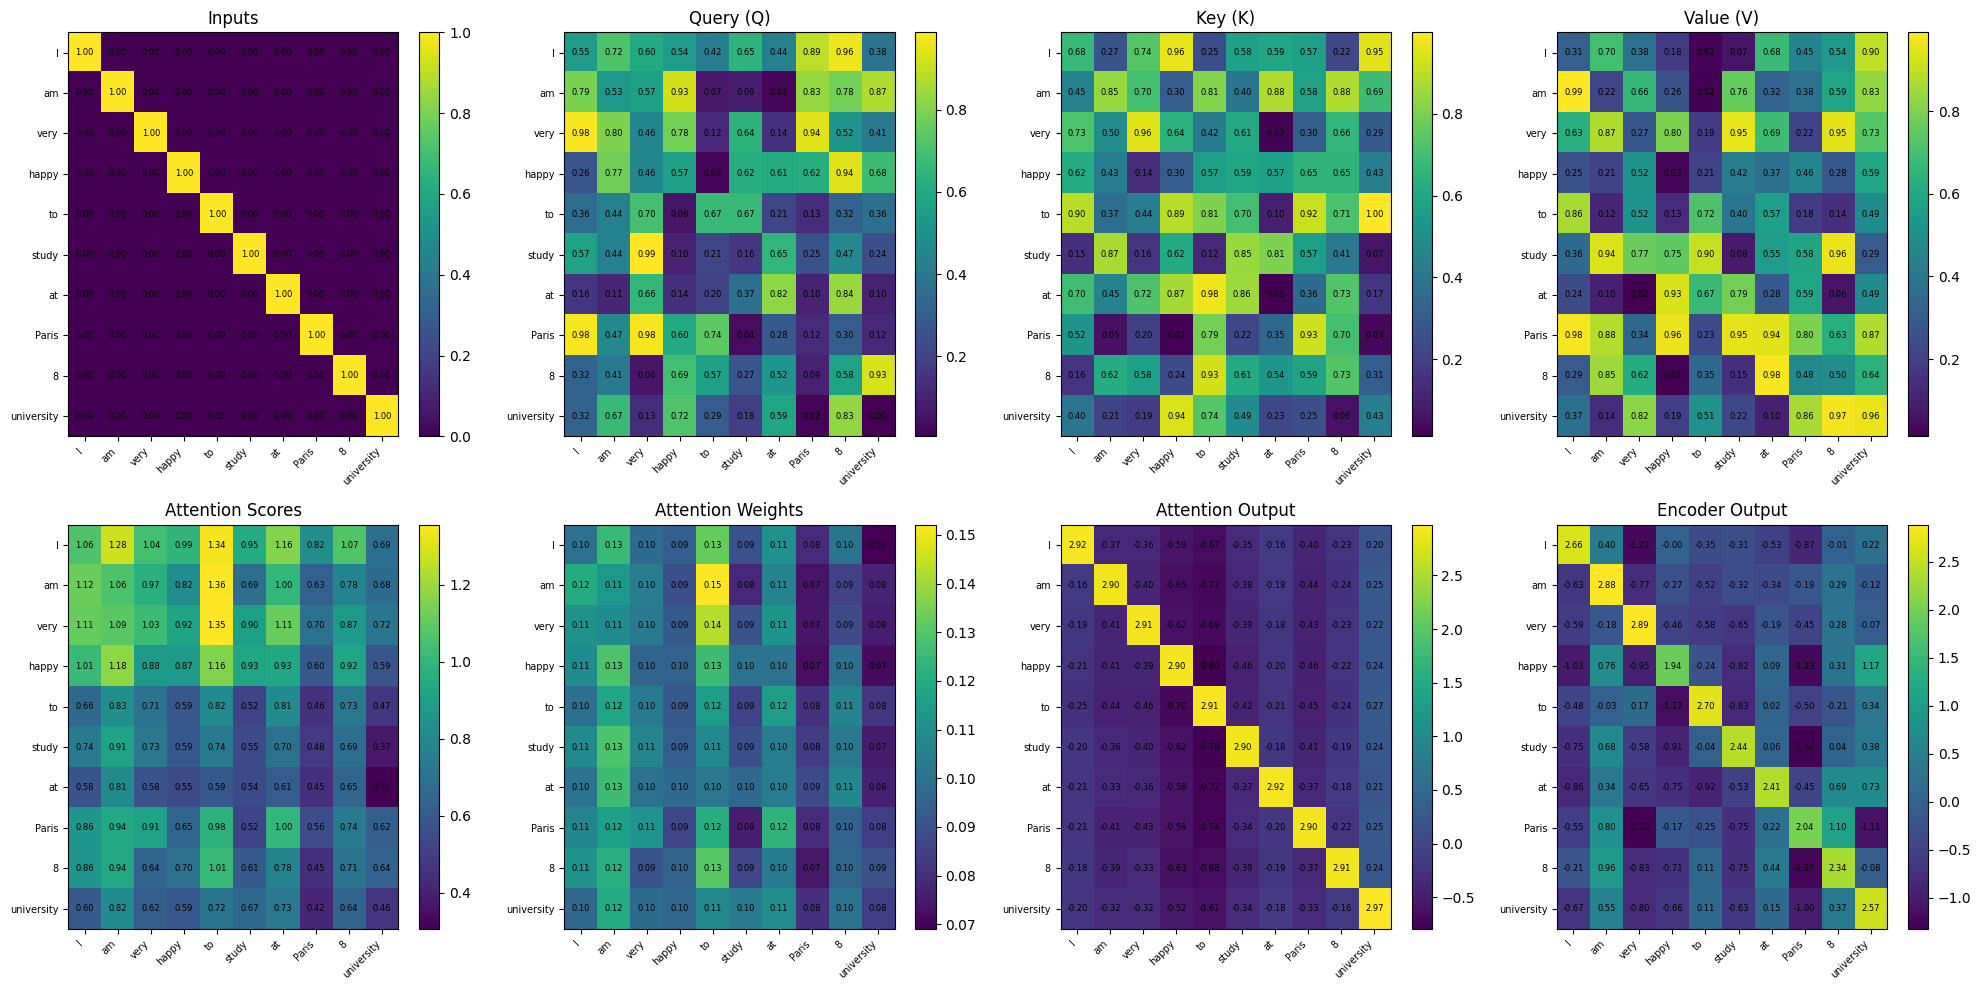

Sentence: ['I', 'am', 'very', 'happy', 'to', 'study', 'at', 'Paris', '8', 'university']

Inputs:
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Query (Q):
 [[0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
  0.43758721 0.891773   0.96366276 0.38344152]
 [0.79172504 0.52889492 0.56804456 0.92559664 0.07103606 0.0871293
  0.0202184  0.83261985 0.77815675 0.87001215]
 [0.97861834 0.79915856 0.46147936 0.78052918 0.11827443 0.63992102
  0.14335329 0.94466892 0.52184832 0.41466194]
 [0.26455561 0.77423369 0.45615033 0.56843395 0.0187898  0.6176355
  0.61209572 0.616934   0.94374808 0.6818203 ]
 [0.3595079  0.43703195 0.6976312  0.06022547 0.66676672 0.67063787
  0.21038256 0.1289263  0.315428

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def layer_norm(x):
    mean = np.mean(x, axis=-1, keepdims=True)
    std = np.std(x, axis=-1, keepdims=True)
    return (x - mean) / std

def plot_heatmap(matrix, title, x_labels=None, y_labels=None, pos=111):
    ax = plt.subplot(pos)
    img = ax.imshow(matrix, aspect="auto")
    ax.set_title(title)

    if x_labels is not None:
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=7)
    else:
        ax.set_xticks(range(matrix.shape[1]))

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=7)
    else:
        ax.set_yticks(range(matrix.shape[0]))

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", color="black", fontsize=6)

    plt.colorbar(img, ax=ax)

sentence = "I am very happy to study at Paris 8 university".split()
vocab_size = len(sentence)

word_to_index = {word: idx for idx, word in enumerate(sentence)}
identity = np.eye(vocab_size)

inputs = np.array([identity[word_to_index[w]] for w in sentence], dtype=float)

np.random.seed(0)

Wq = np.random.rand(vocab_size, vocab_size)
Wk = np.random.rand(vocab_size, vocab_size)
Wv = np.random.rand(vocab_size, vocab_size)
W1 = np.random.rand(vocab_size, vocab_size)
W2 = np.random.rand(vocab_size, vocab_size)

Q = inputs @ Wq
K = inputs @ Wk
V = inputs @ Wv

d_k = K.shape[1]
scores = (Q @ K.T) / np.sqrt(d_k)
attention_weights = softmax(scores)
attention_output = attention_weights @ V

attention_output = layer_norm(attention_output + inputs)

ffn_hidden = attention_output @ W1
ffn_hidden = np.maximum(0, ffn_hidden)
ffn_output = ffn_hidden @ W2

encoder_output = layer_norm(ffn_output + attention_output)

plt.figure(figsize=(20, 10))

plot_heatmap(inputs,"Inputs", x_labels=sentence, y_labels=sentence, pos=241)

plot_heatmap(Q,"Query (Q)", x_labels=sentence, y_labels=sentence, pos=242)

plot_heatmap(K,"Key (K)", x_labels=sentence, y_labels=sentence, pos=243)

plot_heatmap(V,"Value (V)", x_labels=sentence, y_labels=sentence, pos=244)

plot_heatmap(scores,"Attention Scores", x_labels=sentence, y_labels=sentence, pos=245)

plot_heatmap(attention_weights, "Attention Weights", x_labels=sentence, y_labels=sentence, pos=246)

plot_heatmap(attention_output, "Attention Output", x_labels=sentence, y_labels=sentence, pos=247)

plot_heatmap(encoder_output,  "Encoder Output", x_labels=sentence, y_labels=sentence, pos=248)

plt.tight_layout()
plt.show()

print("Sentence:", sentence)
print("\nInputs:\n", inputs)
print("\nQuery (Q):\n", Q)
print("\nKey (K):\n", K)
print("\nValue (V):\n", V)
print("\nAttention Scores:\n", scores)
print("\nAttention Weights:\n", attention_weights)
print("\nAttention Output (Add & Norm):\n", attention_output)
print("\nFeed-Forward Output:\n", ffn_output)
print("\nEncoder Output (final):\n", encoder_output)


![image.png](attachment:image.png)

## Complete Encoder-Decoder Implementation Using Self-Attention

To implement a complete encoder-decoder model using self-attention, we'll extend the previous encoder implementation by adding a decoder component. The decoder will also include self-attention and cross-attention layers to process the encoder outputs and generate predictions.

1. Tokenization and Embedding

 - Tokenization: Both the source (encoder) sentence "I am very happy to work at Paris 8 university" and the target (decoder) sentence "Je suis très heureux de travailler à l'université Paris 8" are tokenized into individual words.

 - Embedding: Each word is converted into a one-hot vector representation. This simple embedding method is used to map each word to a unique vector.

2. Initialize Weights

 - Random weights are initialized for the Query (Q), Key (K), and Value (V) matrices for both the encoder and decoder. Additionally, weights are initialized for the feed-forward layers in both the encoder and decoder.

3. Encoder

 - Self-Attention Layer: The input embeddings are transformed using the Q, K, and V matrices. Attention scores are computed and normalized using softmax to obtain attention weights. These weights are then used to compute the self-attention output.

 - Add & Norm Layer (Self-Attention): Residual connections are added to the self-attention output, and layer normalization is applied.

 - Feed-Forward Layer: The output of the self-attention layer is passed through a feed-forward neural network with ReLU activation.

 - Add & Norm Layer (Feed-Forward): Residual connections are added to the feed-forward output, and layer normalization is applied, resulting in the final encoder output.

4. Decoder

 - Self-Attention Layer: The decoder inputs are transformed using their own Q, K, and V matrices. Attention scores are computed and normalized using softmax to obtain attention weights. These weights are then used to compute the self-attention output for the decoder.

 - Add & Norm Layer (Self-Attention): Residual connections are added to the self-attention output, and layer normalization is applied.

 - Cross-Attention Layer: The decoder's self-attention output interacts with the encoder's output using Q matrices from the decoder and K, V matrices from the encoder. This step allows the decoder to attend to the encoder's outputs. Attention scores are computed and normalized using softmax to obtain cross-attention weights.

 - Add & Norm Layer (Cross-Attention): Residual connections are added to the cross-attention output, and layer normalization is applied.

 - Feed-Forward Layer: The output of the cross-attention layer is passed through a feed-forward neural network with ReLU activation.

 - Add & Norm Layer (Feed-Forward): Residual connections are added to the feed-forward output, and layer normalization is applied, resulting in the final decoder output.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def layer_norm(x):
    mean = np.mean(x, axis=-1, keepdims=True)
    std = np.std(x, axis=-1, keepdims=True)
    return (x - mean) / std

def plot_matrix(matrix, title, x_labels=None, y_labels=None):
    ax = plt.gca()
    img = ax.imshow(matrix, aspect="auto")
    ax.set_title(title, fontsize=9)


    if x_labels is not None:
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=6)
    else:
        ax.set_xticks(range(matrix.shape[1]))

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=6)
    else:
        ax.set_yticks(range(matrix.shape[0]))

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=5, color="black")

    plt.colorbar(img, ax=ax)

encoder_sentence = "I am very happy to study at Paris 8 university".split()
decoder_sentence = "Je suis très heureuse d'étudier à l'université Paris 8".split()

enc_vocab_size = len(encoder_sentence)
dec_vocab_size = len(decoder_sentence)

enc_word_to_idx = {w: i for i, w in enumerate(encoder_sentence)}
dec_word_to_idx = {w: i for i, w in enumerate(decoder_sentence)}

enc_eye = np.eye(enc_vocab_size)
dec_eye = np.eye(dec_vocab_size)

encoder_inputs = np.array([enc_eye[enc_word_to_idx[w]] for w in encoder_sentence], dtype=float)
decoder_inputs = np.array([dec_eye[dec_word_to_idx[w]] for w in decoder_sentence], dtype=float)

np.random.seed(0)


Wq_enc = np.random.rand(enc_vocab_size, enc_vocab_size)
Wk_enc = np.random.rand(enc_vocab_size, enc_vocab_size)
Wv_enc = np.random.rand(enc_vocab_size, enc_vocab_size)
W1_enc = np.random.rand(enc_vocab_size, enc_vocab_size)
W2_enc = np.random.rand(enc_vocab_size, enc_vocab_size)

Wq_dec = np.random.rand(dec_vocab_size, dec_vocab_size)
Wk_dec = np.random.rand(dec_vocab_size, dec_vocab_size)
Wv_dec = np.random.rand(dec_vocab_size, dec_vocab_size)
W1_dec = np.random.rand(dec_vocab_size, dec_vocab_size)
W2_dec = np.random.rand(dec_vocab_size, dec_vocab_size)

Q_enc = encoder_inputs @ Wq_enc
K_enc = encoder_inputs @ Wk_enc
V_enc = encoder_inputs @ Wv_enc

d_k_enc = K_enc.shape[1]
scores_enc = (Q_enc @ K_enc.T) / np.sqrt(d_k_enc)
att_weights_enc = softmax(scores_enc)
att_output_enc = att_weights_enc @ V_enc

att_output_enc = layer_norm(att_output_enc + encoder_inputs)

ffn_hidden_enc = att_output_enc @ W1_enc
ffn_hidden_enc = np.maximum(0, ffn_hidden_enc)
ffn_output_enc = ffn_hidden_enc @ W2_enc

encoder_output = layer_norm(ffn_output_enc + att_output_enc)


Q_dec = decoder_inputs @ Wq_dec
K_dec = decoder_inputs @ Wk_dec
V_dec = decoder_inputs @ Wv_dec

d_k_dec = K_dec.shape[1]
scores


array([[1.06244306, 1.28213084, 1.03714621, 0.99320155, 1.33920278,
        0.95377996, 1.16242009, 0.82412996, 1.0715107 , 0.68759448],
       [1.1214943 , 1.061606  , 0.97367843, 0.82198488, 1.35610379,
        0.69235236, 1.00096208, 0.63355141, 0.78063247, 0.67700967],
       [1.10820616, 1.08834061, 1.02611488, 0.91924182, 1.35475176,
        0.90039154, 1.11036971, 0.69705349, 0.87206012, 0.71627673],
       [1.01406743, 1.17768924, 0.88015938, 0.87486478, 1.15776867,
        0.92922723, 0.92958591, 0.60252109, 0.92135055, 0.58611725],
       [0.66407934, 0.833382  , 0.70567843, 0.59007584, 0.81541032,
        0.51596876, 0.81295466, 0.46079748, 0.73206346, 0.47453544],
       [0.7409728 , 0.91230148, 0.72673052, 0.59110286, 0.74368306,
        0.54715151, 0.70255151, 0.48043827, 0.68666125, 0.37292244],
       [0.58012072, 0.80830674, 0.57557952, 0.54658323, 0.5933979 ,
        0.5420829 , 0.61178651, 0.45164048, 0.64995815, 0.30584603],
       [0.85708925, 0.94107365, 0.9092281

## Complete Encoder-Decoder Implementation Using Multi-Head Self-Attention : A transformer !

This encoder-decoder implementation with multi-head self-attention includes both self-attention and cross-attention mechanisms, residual connections, and layer normalization, demonstrating how the input sentence is transformed and how the decoder attends to the encoder's output to generate the final result. The multi-head attention mechanism allows the model to focus on different parts of the input sentence simultaneously, capturing more complex relationships and context.

1. Tokenization and Embedding

 - Tokenization: Both the source (encoder) sentence "I am very happy to work at Paris 8 university" and the target (decoder) sentence "Je suis très heureux de travailler à l'université Paris 8" are tokenized into individual words.

 - Embedding: Each word is converted into a one-hot vector representation. This simple embedding method is used to map each word to a unique vector.

2. Initialize Weights

 - Random weights are initialized for the Query (Q), Key (K), and Value (V) matrices for both the encoder and decoder, as well as for the feed-forward neural network layers. These weights are necessary for transforming the input embeddings during self-attention and feed-forward processes.

3. Multi-Head Self-Attention

 - Function Definition: The multi_head_attention function splits Q, K, and V matrices into multiple heads, performs self-attention on each head independently, and concatenates the outputs.

4. Encoder

 - Multi-Head Self-Attention Layer: The input embeddings are transformed using the Q, K, and V matrices. The multi_head_attention function is used to compute the self-attention output across multiple heads.

 - Add & Norm Layer (Self-Attention): Residual connections are added to the self-attention output, and layer normalization is applied.

 - Feed-Forward Layer: The output of the self-attention layer is passed through a feed-forward neural network with ReLU activation.

 - Add & Norm Layer (Feed-Forward): Residual connections are added to the feed-forward output, and layer normalization is applied, resulting in the final encoder output.

5. Decoder

 - Multi-Head Self-Attention Layer: The decoder inputs are transformed using their own Q, K, and V matrices. The multi_head_attention function is used to compute the self-attention output across multiple heads for the decoder.

 - Add & Norm Layer (Self-Attention): Residual connections are added to the self-attention output, and layer normalization is applied.

 - Cross-Attention Layer: The decoder's self-attention output interacts with the encoder's output using Q matrices from the decoder and K, V matrices from the encoder. The multi_head_attention function is used to compute the cross-attention output across multiple heads, allowing the decoder to attend to the encoder's outputs.

 - Add & Norm Layer (Cross-Attention): Residual connections are added to the cross-attention output, and layer normalization is applied.

 - Feed-Forward Layer: The output of the cross-attention layer is passed through a feed-forward neural network with ReLU activation.

 - Add & Norm Layer (Feed-Forward): Residual connections are added to the feed-forward output, and layer normalization is applied, resulting in the final decoder output.

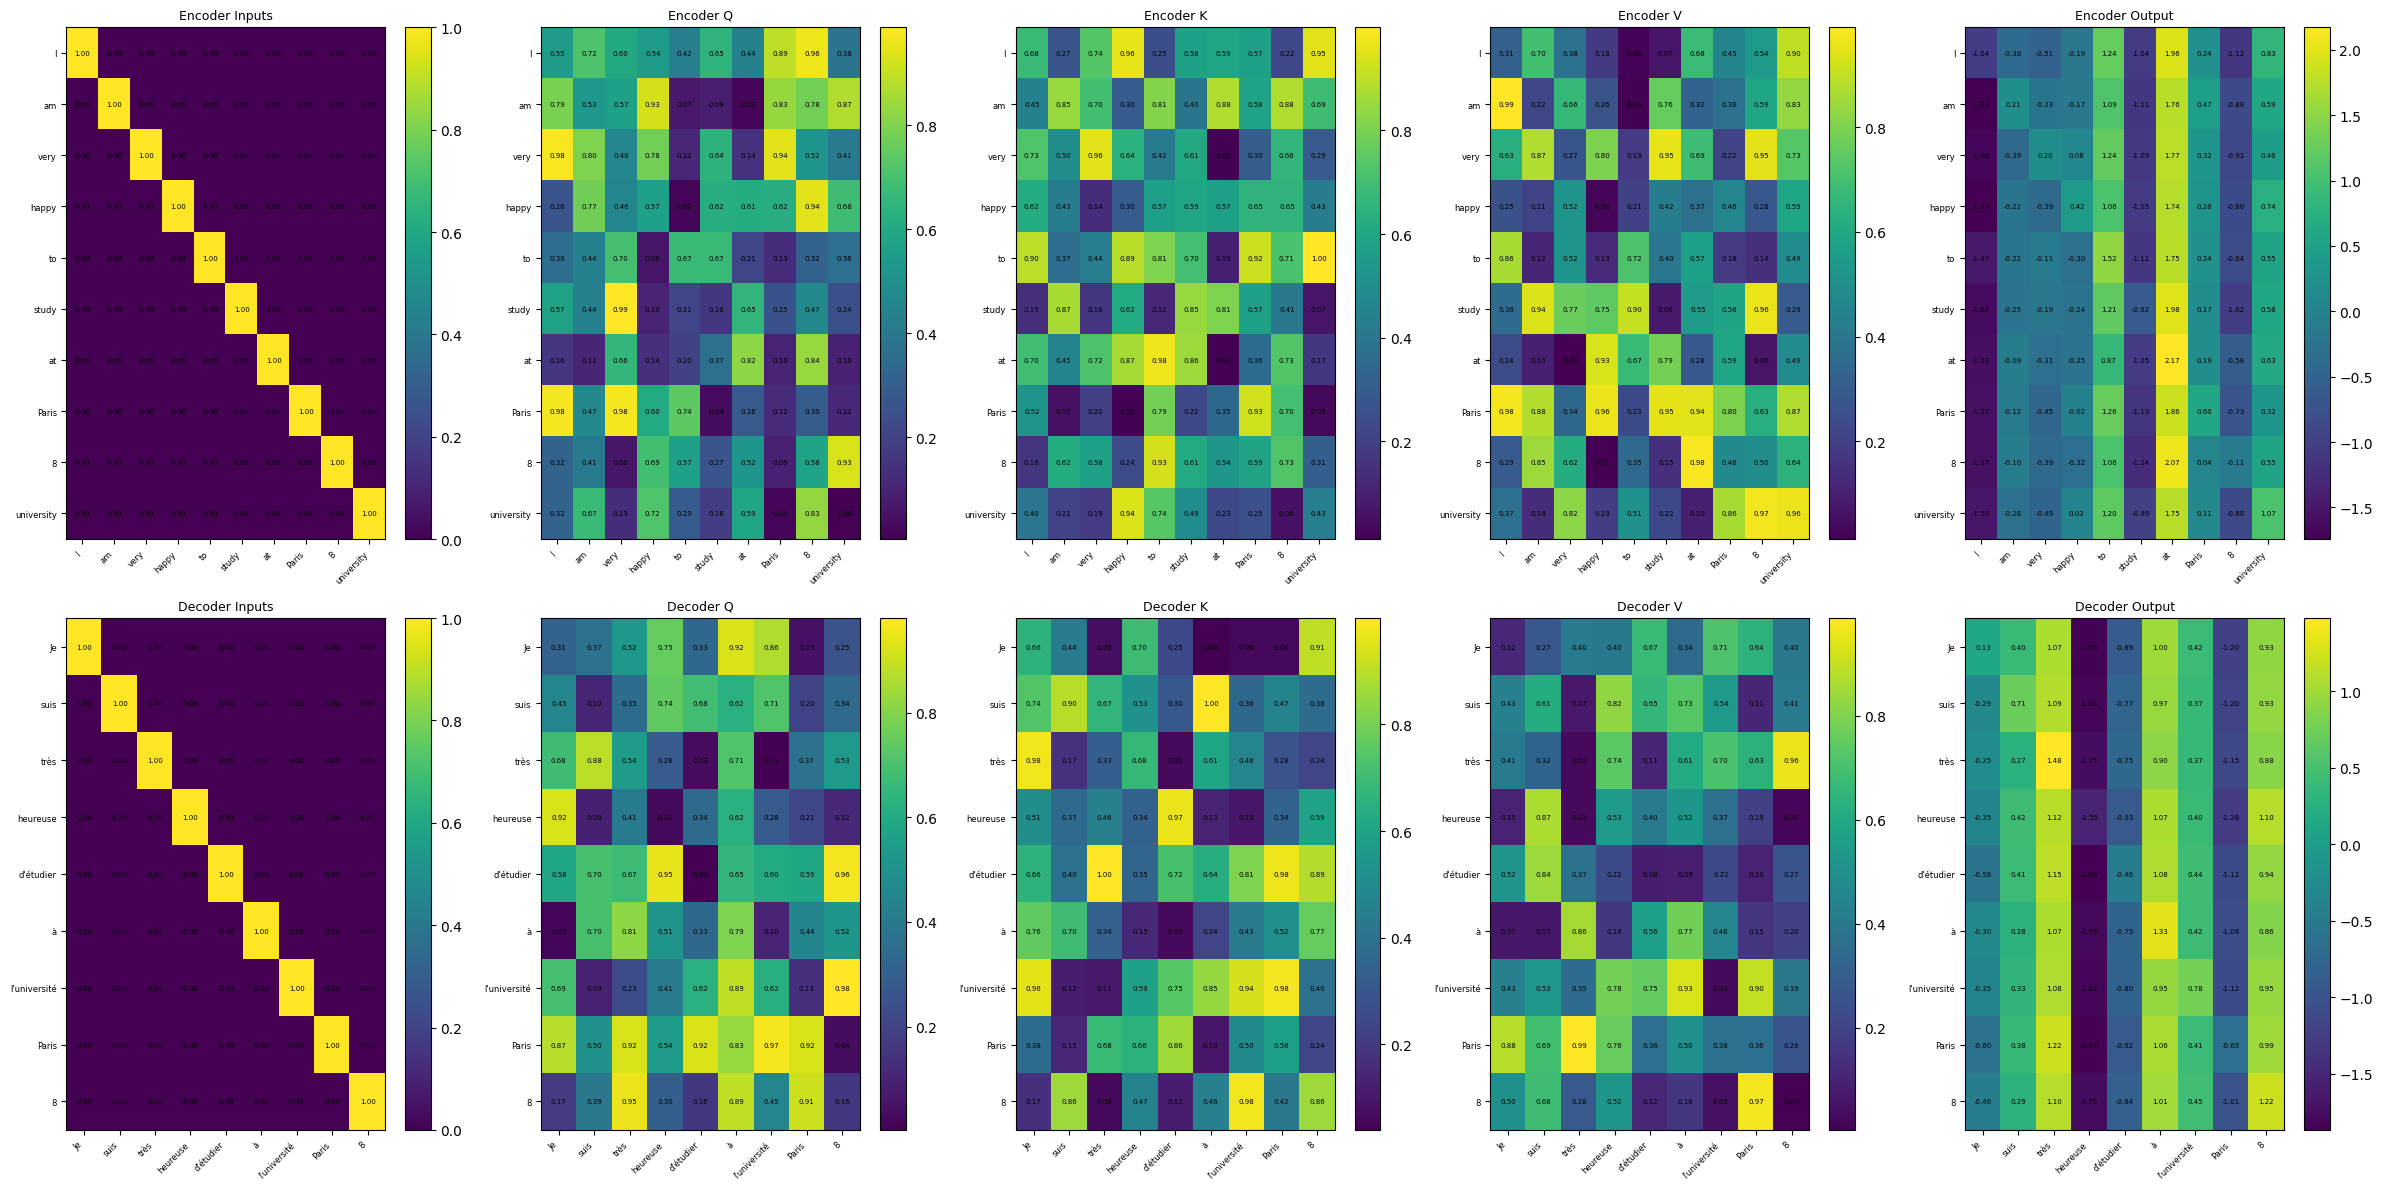

Encoder Output shape: (10, 10)
Decoder Output shape: (9, 9)


In [16]:
import numpy as np
import matplotlib.pyplot as plt


def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def layer_norm(x):
    mean = np.mean(x, axis=-1, keepdims=True)
    std = np.std(x, axis=-1, keepdims=True)
    return (x - mean) / std

def multi_head_attention(Q, K, V, num_heads):
    seq_len_q, d_q = Q.shape
    seq_len_k, d_k = K.shape
    seq_len_v, d_v = V.shape

    head_dim = d_q // num_heads

    Q_heads, K_heads, V_heads = [], [], []

    for _ in range(num_heads):
        Wq = np.random.rand(d_q, head_dim)
        Wk = np.random.rand(d_k, head_dim)
        Wv = np.random.rand(d_v, head_dim)

        Q_heads.append(Q @ Wq)
        K_heads.append(K @ Wk)
        V_heads.append(V @ Wv)
    head_outputs = []
    for i in range(num_heads):
        scores = (Q_heads[i] @ K_heads[i].T) / np.sqrt(head_dim)
        weights = softmax(scores)
        head_outputs.append(weights @ V_heads[i])

    concat = np.concatenate(head_outputs, axis=-1)

    W_out = np.random.rand(concat.shape[-1], d_q)
    return concat @ W_out

def plot_matrix(matrix, title, x_labels=None, y_labels=None):
    ax = plt.gca()
    img = ax.imshow(matrix, aspect="auto")
    ax.set_title(title, fontsize=9)

    if x_labels is not None:
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=6)
    else:
        ax.set_xticks(range(matrix.shape[1]))

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=6)
    else:
        ax.set_yticks(range(matrix.shape[0]))

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=5, color="black")

    plt.colorbar(img, ax=ax)

encoder_sentence = "I am very happy to study at Paris 8 university".split()
decoder_sentence = "Je suis très heureuse d'étudier à l'université Paris 8".split()

enc_vocab_size = len(encoder_sentence)
dec_vocab_size = len(decoder_sentence)

enc_word_to_idx = {w: i for i, w in enumerate(encoder_sentence)}
dec_word_to_idx = {w: i for i, w in enumerate(decoder_sentence)}

enc_eye = np.eye(enc_vocab_size)
dec_eye = np.eye(dec_vocab_size)

encoder_inputs = np.array([enc_eye[enc_word_to_idx[w]] for w in encoder_sentence], dtype=float)
decoder_inputs = np.array([dec_eye[dec_word_to_idx[w]] for w in decoder_sentence], dtype=float)

num_heads = 4
np.random.seed(0)

Wq_encoder = np.random.rand(enc_vocab_size, enc_vocab_size)
Wk_encoder = np.random.rand(enc_vocab_size, enc_vocab_size)
Wv_encoder = np.random.rand(enc_vocab_size, enc_vocab_size)
W1_encoder = np.random.rand(enc_vocab_size, enc_vocab_size)
W2_encoder = np.random.rand(enc_vocab_size, enc_vocab_size)


Wq_decoder = np.random.rand(dec_vocab_size, dec_vocab_size)
Wk_decoder = np.random.rand(dec_vocab_size, dec_vocab_size)
Wv_decoder = np.random.rand(dec_vocab_size, dec_vocab_size)
W1_decoder = np.random.rand(dec_vocab_size, dec_vocab_size)
W2_decoder = np.random.rand(dec_vocab_size, dec_vocab_size)


Q_enc = encoder_inputs @ Wq_encoder
K_enc = encoder_inputs @ Wk_encoder
V_enc = encoder_inputs @ Wv_encoder

att_out_enc = multi_head_attention(Q_enc, K_enc, V_enc, num_heads)
att_out_enc = layer_norm(att_out_enc + encoder_inputs)

ffn_enc = np.maximum(0, att_out_enc @ W1_encoder)
ffn_enc = ffn_enc @ W2_encoder

encoder_output = layer_norm(ffn_enc + att_out_enc)


Q_dec = decoder_inputs @ Wq_decoder
K_dec = decoder_inputs @ Wk_decoder
V_dec = decoder_inputs @ Wv_decoder

att_out_dec = multi_head_attention(Q_dec, K_dec, V_dec, num_heads)
att_out_dec = layer_norm(att_out_dec + decoder_inputs)

Q_cross = att_out_dec @ Wq_decoder
K_cross = encoder_output @ Wk_encoder
V_cross = encoder_output @ Wv_encoder

cross_att_out = multi_head_attention(Q_cross, K_cross, V_cross, num_heads)
cross_att_out = layer_norm(cross_att_out + att_out_dec)


ffn_dec = np.maximum(0, cross_att_out @ W1_decoder)
ffn_dec = ffn_dec @ W2_decoder

decoder_output = layer_norm(ffn_dec + cross_att_out)

plt.figure(figsize=(24, 12))

plt.subplot(2, 5, 1)
plot_matrix(encoder_inputs, "Encoder Inputs",
            x_labels=encoder_sentence, y_labels=encoder_sentence)

plt.subplot(2, 5, 2)
plot_matrix(Q_enc, "Encoder Q",
            x_labels=encoder_sentence, y_labels=encoder_sentence)

plt.subplot(2, 5, 3)
plot_matrix(K_enc, "Encoder K",
            x_labels=encoder_sentence, y_labels=encoder_sentence)

plt.subplot(2, 5, 4)
plot_matrix(V_enc, "Encoder V",
            x_labels=encoder_sentence, y_labels=encoder_sentence)

plt.subplot(2, 5, 5)
plot_matrix(encoder_output, "Encoder Output",
            x_labels=encoder_sentence, y_labels=encoder_sentence)

plt.subplot(2, 5, 6)
plot_matrix(decoder_inputs, "Decoder Inputs",
            x_labels=decoder_sentence, y_labels=decoder_sentence)

plt.subplot(2, 5, 7)
plot_matrix(Q_dec, "Decoder Q",
            x_labels=decoder_sentence, y_labels=decoder_sentence)

plt.subplot(2, 5, 8)
plot_matrix(K_dec, "Decoder K",
            x_labels=decoder_sentence, y_labels=decoder_sentence)

plt.subplot(2, 5, 9)
plot_matrix(V_dec, "Decoder V",
            x_labels=decoder_sentence, y_labels=decoder_sentence)

plt.subplot(2, 5, 10)
plot_matrix(decoder_output, "Decoder Output",
            x_labels=decoder_sentence, y_labels=decoder_sentence)

plt.tight_layout()
plt.show()

print("Encoder Output shape:", encoder_output.shape)
print("Decoder Output shape:", decoder_output.shape)


![image.png](attachment:image.png)

![image.png](attachment:image.png)

## Exercices

### Exercice 3: Self-Attention mechanism: Compute word embeddings

- Use a different sentence to compute word embeddings. Tokenize the sentence and create embeddings using a different method (e.g., Word2Vec or GloVe). Compute the query, key, and value matrices for these new embeddings and visualize the results.
- Change the method for initializing weights for the query, key, and value matrices. Use a different initialization technique (e.g., Xavier initialization) and compute the attention scores and attention weights. Visualize and discuss the impact of weight initialization on the self-attention mechanism.
- Implement a positional encoding mechanism for the sentence. Add positional encodings to the embeddings and compute the query, key, and value matrices. Visualize and explain the role of positional encoding in the self-attention mechanism.

Dans cet exo, nous allons mettre en œuvre progressivement un système de self-attention inspiré des Transformers sur une phrase nouvelle. Dans un premier temps, les vecteurs one-hot seront remplacés par des embeddings denses provenant de Word2Vec (ici représentés par des vecteurs continus aléatoires, imitant le fonctionnement d'un modèle pré-entraîné authentique). À partir de ces embeddings, nous déterminerons les matrices Query, Key et Value, ainsi que les scores d’attention et les poids associés. Par la suite, nous allons changer la méthode d'initialisation des poids en utilisant l'initialisation de Xavier pour observer ses effets sur les cartes d'attention (la stabilité des valeurs et la distribution des poids). Enfin, nous allons ajouter des encodages positionnels sinusoïdaux aux embeddings afin d'intégrer la séquence des mots, recalculer la self-attention, et analyser de quelle manière cette information relative à la position peut influencer la perception de chaque mot par rapport aux autres dans la phrase.

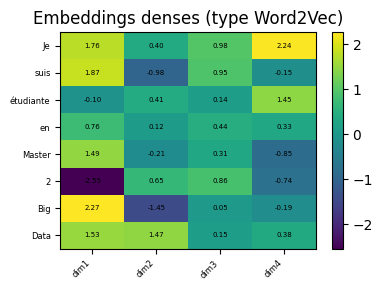

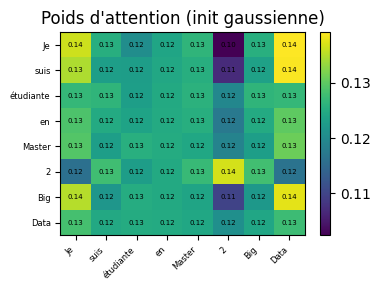

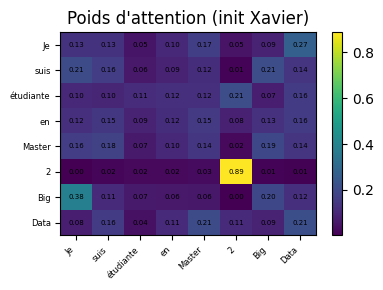

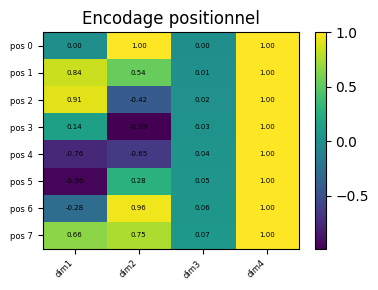

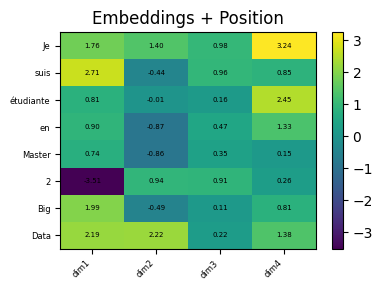

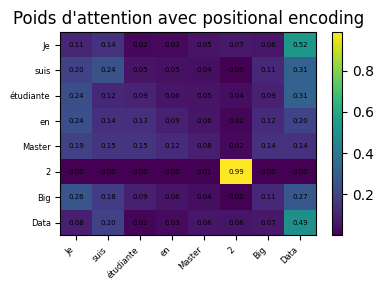

Phrase : ['Je', 'suis', 'étudiante', 'en', 'Master', '2', 'Big', 'Data']

Embeddings denses (premiers vecteurs) :
 [[ 1.76405235  0.40015721  0.97873798  2.2408932 ]
 [ 1.86755799 -0.97727788  0.95008842 -0.15135721]
 [-0.10321885  0.4105985   0.14404357  1.45427351]]

Poids d'attention - init gaussienne (première ligne) :
 [0.1363147  0.12550501 0.12039395 0.12407117 0.12647232 0.10245696
 0.12564175 0.13914412]

Poids d'attention - init Xavier (première ligne) :
 [0.13247313 0.13203838 0.05288751 0.10440387 0.16544415 0.04977461
 0.08836283 0.27461552]

Poids d'attention avec positional encoding (première ligne) :
 [0.10789821 0.14324275 0.02177004 0.02689425 0.0505823  0.06688908
 0.06114999 0.52157338]


In [18]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6.0 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, size=(in_dim, out_dim))

def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            angle = pos / (10000 ** (i / d_model))
            pe[pos, i] = np.sin(angle)
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(angle)
    return pe

def plot_matrix(matrix, title, x_labels=None, y_labels=None):
    plt.figure(figsize=(4, 3))
    plt.imshow(matrix, aspect="auto")
    plt.colorbar()
    plt.title(title)

    if x_labels is not None:
        plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right", fontsize=6)
    else:
        plt.xticks(range(matrix.shape[1]))

    if y_labels is not None:
        plt.yticks(range(len(y_labels)), y_labels, fontsize=6)
    else:
        plt.yticks(range(matrix.shape[0]))

    if matrix.shape[0] <= 10 and matrix.shape[1] <= 10:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                plt.text(j, i, f"{matrix[i, j]:.2f}",
                         ha="center", va="center", fontsize=5, color="black")

    plt.tight_layout()
    plt.show()

sentence = "Je suis étudiante en Master 2 Big Data".split()
tokens = list(dict.fromkeys(sentence))
vocab_size = len(tokens)
d_model = 4

np.random.seed(0)
word_to_idx = {w: i for i, w in enumerate(tokens)}
embedding_matrix = np.random.randn(vocab_size, d_model)

inputs = np.array([embedding_matrix[word_to_idx[w]] for w in sentence])
seq_len = inputs.shape[0]

plot_matrix(inputs, "Embeddings denses (type Word2Vec)", x_labels=[f"dim{i+1}" for i in range(d_model)], y_labels=sentence)


Wq_std = np.random.randn(d_model, d_model) * 0.1
Wk_std = np.random.randn(d_model, d_model) * 0.1
Wv_std = np.random.randn(d_model, d_model) * 0.1

Q_std = inputs @ Wq_std
K_std = inputs @ Wk_std
V_std = inputs @ Wv_std

scores_std = (Q_std @ K_std.T) / np.sqrt(d_model)
attn_std = softmax(scores_std)

plot_matrix(attn_std, "Poids d'attention (init gaussienne)", x_labels=sentence, y_labels=sentence)

Wq_xav = xavier_init(d_model, d_model)
Wk_xav = xavier_init(d_model, d_model)
Wv_xav = xavier_init(d_model, d_model)

Q_xav = inputs @ Wq_xav
K_xav = inputs @ Wk_xav
V_xav = inputs @ Wv_xav

scores_xav = (Q_xav @ K_xav.T) / np.sqrt(d_model)
attn_xav = softmax(scores_xav)

plot_matrix(attn_xav, "Poids d'attention (init Xavier)", x_labels=sentence, y_labels=sentence)

pos_enc = positional_encoding(seq_len, d_model)

inputs_pos = inputs + pos_enc

plot_matrix(pos_enc, "Encodage positionnel", x_labels=[f"dim{i+1}" for i in range(d_model)], y_labels=[f"pos {i}" for i in range(seq_len)])
plot_matrix(inputs_pos, "Embeddings + Position", x_labels=[f"dim{i+1}" for i in range(d_model)], y_labels=sentence)

Q_pos = inputs_pos @ Wq_xav
K_pos = inputs_pos @ Wk_xav
V_pos = inputs_pos @ Wv_xav

scores_pos = (Q_pos @ K_pos.T) / np.sqrt(d_model)
attn_pos = softmax(scores_pos)

plot_matrix(attn_pos, "Poids d'attention avec positional encoding", x_labels=sentence, y_labels=sentence)


print("Phrase :", sentence)
print("\nEmbeddings denses (premiers vecteurs) :\n", inputs[:3])
print("\nPoids d'attention - init gaussienne (première ligne) :\n", attn_std[0])
print("\nPoids d'attention - init Xavier (première ligne) :\n", attn_xav[0])
print("\nPoids d'attention avec positional encoding (première ligne) :\n", attn_pos[0])


### Exercice 4: Self-Attention mechanism: Varying Parameters

- Modify the dimensionality of the embeddings for a given sentence. Experiment with embedding dimensions of 4, 8, and 16. Compute the query, key, and value matrices for each case. Visualize and compare the attention weights and outputs for different embedding dimensions.
- Change the number of attention heads to 4 and implement the multi-head attention mechanism. Compute and visualize the attention weights and output. Compare the results with single-head and two-head attention.
- Implement dropout in the attention mechanism. Apply dropout to the attention weights before computing the final attention output. Visualize the results with and without dropout and discuss the impact on the attention mechanism.

Dans cet exo, nous examinons l'impact des différents paramètres du système de self-attention. Nous commençons par ajuster la taille des embeddings (4, 8 et 16) pour une phrase identique, avant de procéder au calcul des matrices Query, Key, Value et des poids d’attention, afin d'observer visuellement l'effet de la dimension sur la focalisation de l'attention. Par la suite, nous mettons en œuvre la multi-head attention avec 1, 2 et 4 têtes (en utilisant des embeddings de dimension 16) pour analyser comment un plus grand nombre de têtes permet de saisir divers “angles” sur les relations entre les mots. Enfin, nous intégrons du dropout directement sur les poids d’attention avant de calculer le résultat, et nous comparons les cartes d’attention et les résultats obtenus avec et sans dropout pour examiner comment cette technique de régularisation peut atténuer la certitude de l’attention et potentiellement augmenter sa robustesse.

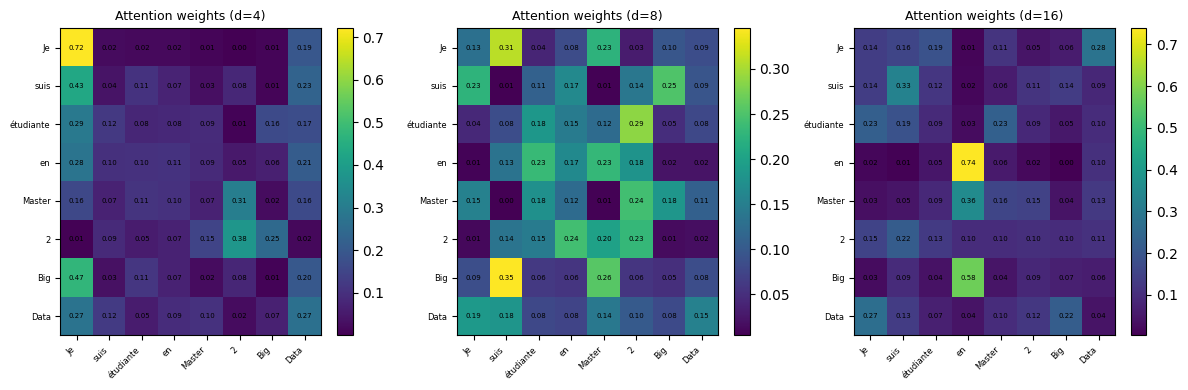

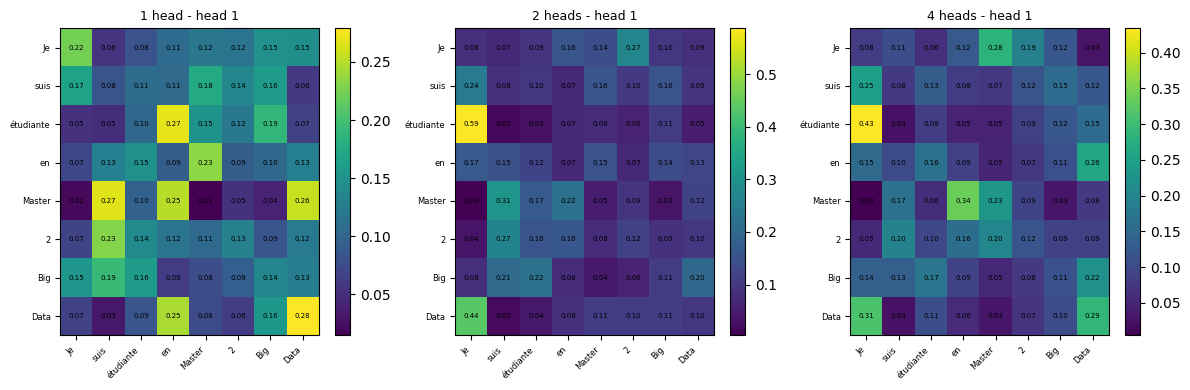

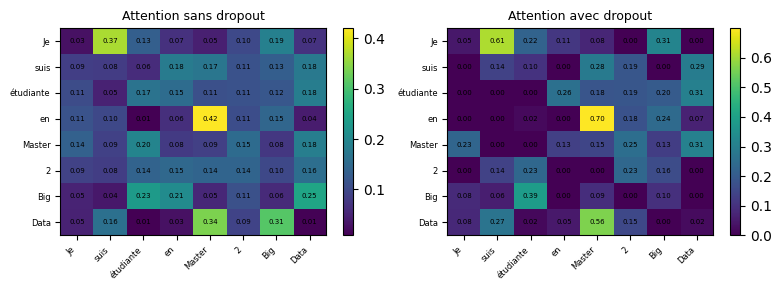

Output shapes pour différentes dimensions d'embedding :
d=4 -> (8, 4)
d=8 -> (8, 8)
d=16 -> (8, 16)

Multi-head attention (d=16) :
1 head : (8, 16) | 2 heads : (8, 16) | 4 heads : (8, 16)

Self-attention avec et sans dropout (d=16) :
Sans dropout : (8, 16) | Avec dropout : (8, 16)


In [22]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6.0 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, size=(in_dim, out_dim))

def plot_heatmap(mat, title, x_labels, y_labels):
    plt.imshow(mat, aspect='auto')
    plt.colorbar()
    plt.title(title, fontsize=9)

    plt.xticks(range(len(x_labels)), x_labels,
               rotation=45, ha='right', fontsize=6)
    plt.yticks(range(len(y_labels)), y_labels, fontsize=6)

    if mat.shape[0] <= 10 and mat.shape[1] <= 10:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                plt.text(j, i, f"{mat[i, j]:.2f}",
                         ha='center', va='center', fontsize=5, color='black')

    plt.tight_layout()

def self_attention_xavier(inputs):
    seq_len, d_model = inputs.shape

    Wq = xavier_init(d_model, d_model)
    Wk = xavier_init(d_model, d_model)
    Wv = xavier_init(d_model, d_model)

    Q = inputs @ Wq
    K = inputs @ Wk
    V = inputs @ Wv

    scores = (Q @ K.T) / np.sqrt(d_model)
    weights = softmax(scores)
    output = weights @ V

    return Q, K, V, weights, output

def multi_head_attention(inputs, num_heads):

    seq_len, d_model = inputs.shape
    assert d_model % num_heads == 0, "d_model doit être divisible par le nombre de têtes."
    d_head = d_model // num_heads

    Wq = xavier_init(d_model, d_model)
    Wk = xavier_init(d_model, d_model)
    Wv = xavier_init(d_model, d_model)
    Wo = xavier_init(d_model, d_model)

    Q = inputs @ Wq
    K = inputs @ Wk
    V = inputs @ Wv

    head_weights = []
    head_outputs = []

    for h in range(num_heads):
        q_h = Q[:, h*d_head:(h+1)*d_head]
        k_h = K[:, h*d_head:(h+1)*d_head]
        v_h = V[:, h*d_head:(h+1)*d_head]

        scores_h = (q_h @ k_h.T) / np.sqrt(d_head)
        w_h = softmax(scores_h)
        out_h = w_h @ v_h

        head_weights.append(w_h)
        head_outputs.append(out_h)

    concat = np.concatenate(head_outputs, axis=-1)
    output = concat @ Wo

    return np.array(head_weights), output

def dropout(x, drop_rate):

    mask = (np.random.rand(*x.shape) > drop_rate).astype(float)
    return (x * mask) / (1.0 - drop_rate)

sentence = "Je suis étudiante en Master 2 Big Data".split()

tokens = list(dict.fromkeys(sentence))
vocab_size = len(tokens)

word_to_idx = {w: i for i, w in enumerate(tokens)}



np.random.seed(0)
dims = [4, 8, 16]
attn_by_dim = {}
out_by_dim = {}

for d_model in dims:
    emb_matrix = np.random.randn(vocab_size, d_model)
    inputs = np.array([emb_matrix[word_to_idx[w]] for w in sentence])

    Q, K, V, weights, output = self_attention_xavier(inputs)
    attn_by_dim[d_model] = weights
    out_by_dim[d_model] = output

plt.figure(figsize=(12, 4))
for i, d_model in enumerate(dims, start=1):
    plt.subplot(1, 3, i)
    plot_heatmap(attn_by_dim[d_model],
                 f"Attention weights (d={d_model})",
                 sentence, sentence)
plt.show()


d_model = 16
np.random.seed(1)
emb16 = np.random.randn(vocab_size, d_model)
inputs16 = np.array([emb16[word_to_idx[w]] for w in sentence])

np.random.seed(2)
w_1, out_1 = multi_head_attention(inputs16, 1)

np.random.seed(2)
w_2, out_2 = multi_head_attention(inputs16, 2)

np.random.seed(2)
w_4, out_4 = multi_head_attention(inputs16, 4)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plot_heatmap(w_1[0], "1 head - head 1", sentence, sentence)

plt.subplot(1, 3, 2)
plot_heatmap(w_2[0], "2 heads - head 1", sentence, sentence)

plt.subplot(1, 3, 3)
plot_heatmap(w_4[0], "4 heads - head 1", sentence, sentence)

plt.show()

np.random.seed(3)
Qd, Kd, Vd, w_no_dropout, out_no_dropout = self_attention_xavier(inputs16)

drop_rate = 0.4
np.random.seed(4)
w_with_dropout = dropout(w_no_dropout, drop_rate)
out_with_dropout = w_with_dropout @ Vd

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plot_heatmap(w_no_dropout, "Attention sans dropout", sentence, sentence)

plt.subplot(1, 2, 2)
plot_heatmap(w_with_dropout, "Attention avec dropout", sentence, sentence)

plt.show()

print("Output shapes pour différentes dimensions d'embedding :")
for d_model in dims:
    print(f"d={d_model} -> {out_by_dim[d_model].shape}")

print("\nMulti-head attention (d=16) :")
print("1 head :", out_1.shape, "| 2 heads :", out_2.shape, "| 4 heads :", out_4.shape)

print("\nSelf-attention avec et sans dropout (d=16) :")
print("Sans dropout :", out_no_dropout.shape, "| Avec dropout :", out_with_dropout.shape)


### Exercice 5: Self-Attention mechanism: Advanced Techniques

- Implement layer normalization before and after the attention mechanism. Compare the results of both approaches by visualizing the attention weights and outputs. Discuss the impact of layer normalization on the self-attention mechanism.
- Experiment with different activation functions in the feed-forward layer following the attention mechanism. Replace ReLU with other functions (e.g., Leaky ReLU, ELU). Compute and visualize the attention outputs for each activation function and compare the results.
- Implement a mechanism to handle variable-length sequences using masking. Compute the attention scores and apply the mask to ignore padding tokens. Visualize the attention weights and outputs with and without masking and discuss the differences.

Dans cet exo, nous examinons des versions plus sophistiquées du mécanisme de l’auto-attention. Premièrement, nous effectuons la normalisation de couche soit avant soit après le bloc d’attention afin de comparer leurs impacts sur les poids et les résultats (norme avant ou après). Puis, nous intégrons une couche de propagation avant après l’auto-attention, tout en remplaçant la fonction d’activation ReLU par d'autres alternatives (Leaky ReLU, ELU) pour analyser comment cela influence les représentations générées. Pour terminer, nous introduisons un masque pour gérer des séquences ayant des longueurs variées : certains tokens représentent des rembourrages qui ne doivent pas affecter l’attention. Nous examinons visuellement les poids d’attention et les résultats avec et sans masque pour bien saisir l’importance de cette étape dans les Transformers.

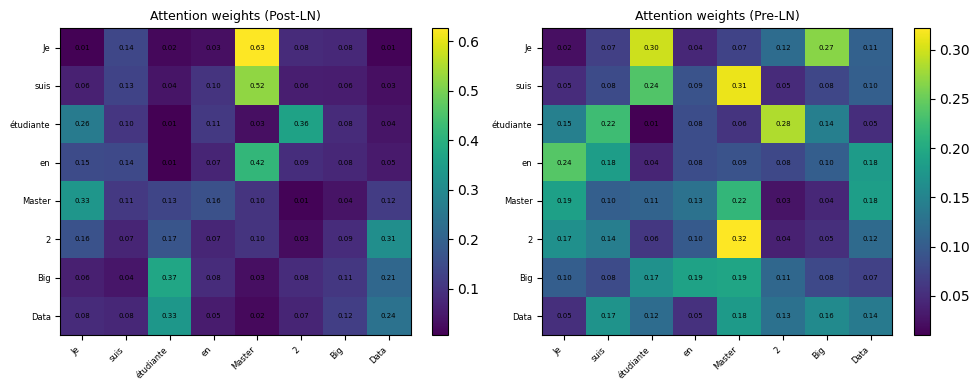

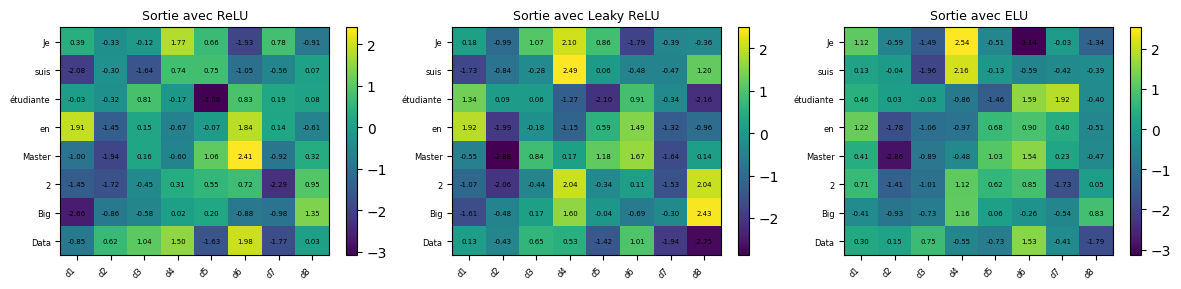

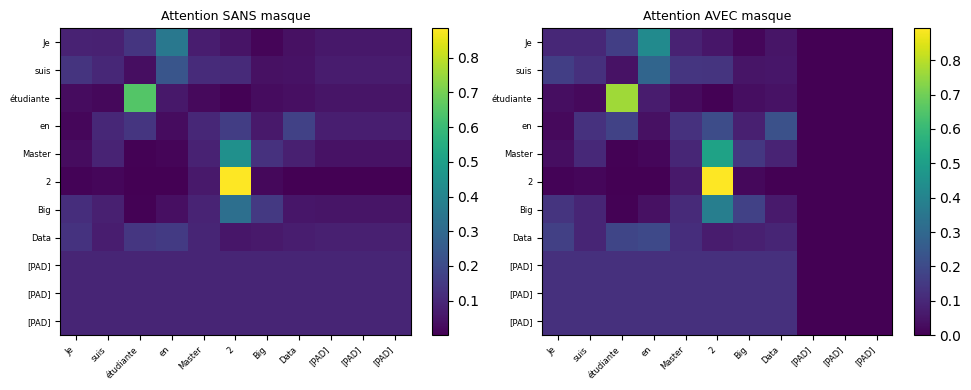

Shapes :
Post-LN output : (8, 8) | Pre-LN output : (8, 8)
FFN ReLU / LeakyReLU / ELU : (8, 8) (8, 8) (8, 8)
Padded outputs sans / avec masque : (11, 8) (11, 8)


In [24]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def layer_norm(x, eps=1e-6):
    mean = np.mean(x, axis=-1, keepdims=True)
    var = np.var(x, axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)

def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6.0 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, size=(in_dim, out_dim))

def plot_heatmap(mat, title, x_labels, y_labels):
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.title(title, fontsize=9)

    plt.xticks(range(len(x_labels)), x_labels,
               rotation=45, ha='right', fontsize=6)
    plt.yticks(range(len(y_labels)), y_labels, fontsize=6)

    if mat.shape[0] <= 10 and mat.shape[1] <= 10:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                plt.text(j, i, f"{mat[i, j]:.2f}",
                         ha='center', va='center', fontsize=5, color='black')
    plt.tight_layout()

def self_attention(inputs, pre_ln=False, post_ln=True, mask=None):
    x = inputs

    if pre_ln:
        x_norm = layer_norm(x)
    else:
        x_norm = x

    seq_len, d_model = x_norm.shape

    Wq = xavier_init(d_model, d_model)
    Wk = xavier_init(d_model, d_model)
    Wv = xavier_init(d_model, d_model)

    Q = x_norm @ Wq
    K = x_norm @ Wk
    V = x_norm @ Wv

    scores = (Q @ K.T) / np.sqrt(d_model)

    if mask is not None:
        for i in range(seq_len):
            for j in range(seq_len):
                if mask[j] == 0:
                    scores[i, j] = -1e9

    weights = softmax(scores)
    att_out = weights @ V

    y = x + att_out

    if post_ln:
        y = layer_norm(y)

    return weights, y

def activation(x, name="relu"):
    if name == "relu":
        return np.maximum(0, x)
    if name == "leaky_relu":
        return np.where(x > 0, x, 0.1 * x)
    if name == "elu":
        return np.where(x > 0, x, np.exp(x) - 1)
    return x

def feed_forward(x, act_name="relu"):
    d_model = x.shape[1]
    d_hidden = 2 * d_model

    W1 = xavier_init(d_model, d_hidden)
    W2 = xavier_init(d_hidden, d_model)

    h = activation(x @ W1, act_name)
    y = h @ W2
    return y

sentence = "Je suis étudiante en Master 2 Big Data".split()
seq_len = len(sentence)
d_model = 8

np.random.seed(0)

emb_matrix = np.random.randn(len(sentence), d_model)
inputs = emb_matrix


np.random.seed(1)
w_post, out_post = self_attention(inputs, pre_ln=False, post_ln=True, mask=None)

np.random.seed(1)
w_pre, out_pre = self_attention(inputs, pre_ln=True, post_ln=False, mask=None)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_heatmap(w_post, "Attention weights (Post-LN)", sentence, sentence)
plt.subplot(1, 2, 2)
plot_heatmap(w_pre, "Attention weights (Pre-LN)", sentence, sentence)
plt.show()


np.random.seed(2)
_, base_out = self_attention(inputs, pre_ln=False, post_ln=True)

ff_relu = base_out + feed_forward(base_out, "relu")
ff_lrelu = base_out + feed_forward(base_out, "leaky_relu")
ff_elu = base_out + feed_forward(base_out, "elu")

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plot_heatmap(ff_relu, "Sortie avec ReLU", [f"d{i+1}" for i in range(d_model)], sentence)
plt.subplot(1, 3, 2)
plot_heatmap(ff_lrelu, "Sortie avec Leaky ReLU", [f"d{i+1}" for i in range(d_model)], sentence)
plt.subplot(1, 3, 3)
plot_heatmap(ff_elu, "Sortie avec ELU", [f"d{i+1}" for i in range(d_model)], sentence)
plt.show()

pad_token = "[PAD]"
padded_sentence = sentence + [pad_token] * 3
padded_len = len(padded_sentence)

padded_inputs = np.zeros((padded_len, d_model))
padded_inputs[:seq_len] = inputs

mask = np.array([1]*seq_len + [0]*3)

np.random.seed(3)
w_no_mask, out_no_mask = self_attention(padded_inputs, pre_ln=False, post_ln=True, mask=None)

np.random.seed(3)
w_mask, out_mask = self_attention(padded_inputs, pre_ln=False, post_ln=True, mask=mask)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_heatmap(w_no_mask, "Attention SANS masque", padded_sentence, padded_sentence)
plt.subplot(1, 2, 2)
plot_heatmap(w_mask, "Attention AVEC masque", padded_sentence, padded_sentence)
plt.show()

print("Shapes :")
print("Post-LN output :", out_post.shape, "| Pre-LN output :", out_pre.shape)
print("FFN ReLU / LeakyReLU / ELU :", ff_relu.shape, ff_lrelu.shape, ff_elu.shape)
print("Padded outputs sans / avec masque :", out_no_mask.shape, out_mask.shape)


### Exercice 6: Self-Attention mechanism: Applications

- Apply the self-attention mechanism to a sentence with named entities (e.g., "Barack Obama was the 44th president of the United States"). Compute the query, key, and value matrices, and visualize the attention weights. Discuss how the self-attention mechanism handles named entities.
- Use the self-attention mechanism for a sequence-to-sequence task (e.g., translation). Compute the attention weights for both the encoder and decoder sequences. Visualize the results and discuss how the attention mechanism captures the relationships between input and output sequences.
- Implement a self-attention mechanism for a text classification task. Compute the attention weights for a sentence and use the final attention output as features for classification. Visualize the attention weights and discuss how the self-attention mechanism helps in identifying important features for classification.

Dans cet exo, nous mettons en œuvre la self-attention dans trois situations typiques. Pour commencer, nous prenons une phrase avec des entités nommées pour examiner la distribution de l’attention entre des termes tels que “Barack”, “Obama” ou “United States”. Ensuite, nous développons rapidement un modèle de type encodeur-décodeur : une phrase source en anglais, une phrase cible en français, un bloc de self-attention du côté encodeur et un bloc de cross-attention du côté décodeur, afin de montrer de quelle manière les mots dans la sortie se rapportent aux mots dans l’entrée. Pour finir, nous élaborons un petit exemple d’analyse de texte : nous évaluons les poids d’attention sur une phrase et utilisons les résultats d’attention en tant que vecteur de caractéristiques pour déterminer une classe ; nous visualisons alors quels mots sont perçus comme significatifs par le mécanisme d’attention.

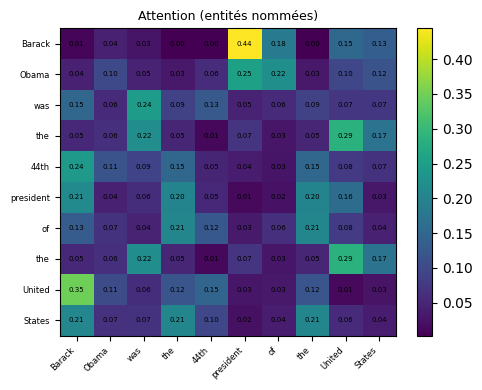

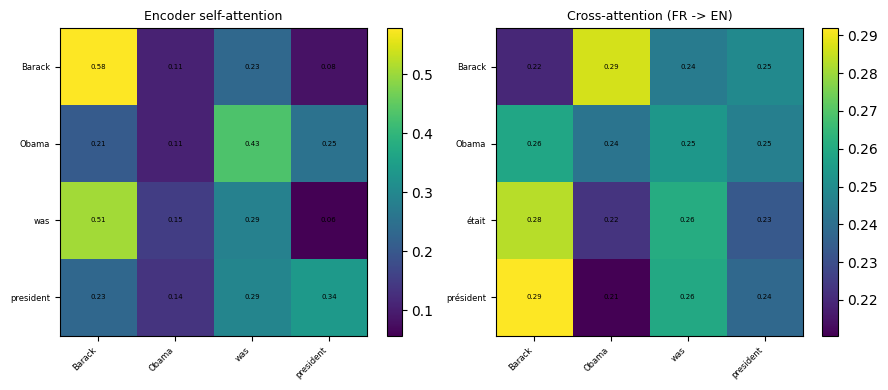

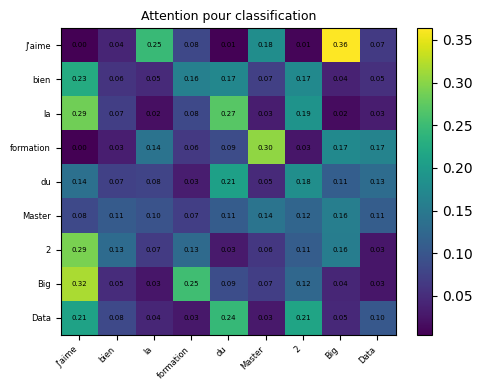

Probabilités de classe (jouet) [neg, pos] : [0.493 0.507]


In [26]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6.0 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, size=(in_dim, out_dim))

def plot_heatmap(mat, title, x_labels, y_labels):
    plt.imshow(mat, aspect="auto")
    plt.title(title, fontsize=9)
    plt.colorbar()

    plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right", fontsize=6)
    plt.yticks(range(len(y_labels)), y_labels, fontsize=6)

    if mat.shape[0] <= 12 and mat.shape[1] <= 12:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                plt.text(j, i, f"{mat[i, j]:.2f}",
                         ha="center", va="center", fontsize=5, color="black")

    plt.tight_layout()

def self_attention(inputs):
    seq_len, d_model = inputs.shape

    Wq = xavier_init(d_model, d_model)
    Wk = xavier_init(d_model, d_model)
    Wv = xavier_init(d_model, d_model)

    Q = inputs @ Wq
    K = inputs @ Wk
    V = inputs @ Wv

    scores = (Q @ K.T) / np.sqrt(d_model)
    weights = softmax(scores)
    output = weights @ V
    return Q, K, V, weights, output

def cross_attention(query_inputs, key_inputs, value_inputs):
    seq_q, d_model = query_inputs.shape
    seq_k, _ = key_inputs.shape

    Wq = xavier_init(d_model, d_model)
    Wk = xavier_init(d_model, d_model)
    Wv = xavier_init(d_model, d_model)

    Q = query_inputs @ Wq
    K = key_inputs @ Wk
    V = value_inputs @ Wv

    scores = (Q @ K.T) / np.sqrt(d_model)
    weights = softmax(scores)
    output = weights @ V

    return weights, output

np.random.seed(0)


sentence_ne = "Barack Obama was the 44th president of the United States".split()
d_model = 8

vocab_ne = list(dict.fromkeys(sentence_ne))
word2idx_ne = {w: i for i, w in enumerate(vocab_ne)}
emb_ne = np.random.randn(len(vocab_ne), d_model)

inputs_ne = np.array([emb_ne[word2idx_ne[w]] for w in sentence_ne])

Q_ne, K_ne, V_ne, attn_ne, out_ne = self_attention(inputs_ne)

plt.figure(figsize=(5, 4))
plot_heatmap(attn_ne, "Attention (entités nommées)", sentence_ne, sentence_ne)
plt.show()


enc_sentence = "Barack Obama was president".split()
dec_sentence = "Barack Obama était président".split()

d_model = 8

vocab_all = list(dict.fromkeys(enc_sentence + dec_sentence))
word2idx = {w: i for i, w in enumerate(vocab_all)}
emb_all = np.random.randn(len(vocab_all), d_model)

enc_inputs = np.array([emb_all[word2idx[w]] for w in enc_sentence])
dec_inputs = np.array([emb_all[word2idx[w]] for w in dec_sentence])

Q_enc, K_enc, V_enc, attn_enc, out_enc = self_attention(enc_inputs)

attn_cross, out_dec = cross_attention(dec_inputs, out_enc, out_enc)

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plot_heatmap(attn_enc, "Encoder self-attention", enc_sentence, enc_sentence)

plt.subplot(1, 2, 2)
plot_heatmap(attn_cross, "Cross-attention (FR -> EN)", enc_sentence, dec_sentence)

plt.show()

sentence_clf = "J'aime bien la formation du Master 2 Big Data".split()
d_model = 8

vocab_clf = list(dict.fromkeys(sentence_clf))
word2idx_clf = {w: i for i, w in enumerate(vocab_clf)}
emb_clf = np.random.randn(len(vocab_clf), d_model)

inputs_clf = np.array([emb_clf[word2idx_clf[w]] for w in sentence_clf])

Q_c, K_c, V_c, attn_c, out_c = self_attention(inputs_clf)

features = out_c.mean(axis=0)

# 2 classes : 0 = négatif, 1 = positif
W_cls = xavier_init(d_model, 2)
b_cls = np.zeros(2)
logits = features @ W_cls + b_cls
probs = softmax(logits.reshape(1, -1))[0]

plt.figure(figsize=(5, 4))
plot_heatmap(attn_c, "Attention pour classification", sentence_clf, sentence_clf)
plt.show()

print("Probabilités de classe (jouet) [neg, pos] :", probs.round(3))
